In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import sqlite3
from tqdm import tqdm
import matplotlib.dates as mdates
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.dates import DateFormatter

In [2]:
def fetch_between_dates(start_date, end_date, db_name="data.db", table_name="sensor_data"):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()
    
    cursor.execute(f"""
        SELECT * FROM {table_name} WHERE timestamp BETWEEN ? AND ?
    """, (start_date, end_date))
    
    rows = cursor.fetchall()
    conn.close()

    if not rows:
        return np.array([])
    
    return np.array(rows)

def convert_timestamp(timestamp_str):
    dt = datetime.fromisoformat(timestamp_str)
    return pd.Timestamp(dt.strftime('%Y-%m-%d %H:%M:%S'))

In [3]:
feature_set = ['Active Power', 'Reactive Power', 'Governor speed actual', 'UGB X displacement', 'UGB Y displacement',
    'LGB X displacement', 'LGB Y displacement', 'TGB X displacement',
    'TGB Y displacement', 'Stator winding temperature 13',
    'Stator winding temperature 14', 'Stator winding temperature 15',
    'Surface Air Cooler Air Outlet Temperature',
    'Surface Air Cooler Water Inlet Temperature',
    'Surface Air Cooler Water Outlet Temperature',
    'Stator core temperature', 'UGB metal temperature',
    'LGB metal temperature 1', 'LGB metal temperature 2',
    'LGB oil temperature', 'Penstock Flow', 'Turbine flow',
    'UGB cooling water flow', 'LGB cooling water flow',
    'Generator cooling water flow', 'Governor Penstock Pressure',
    'Penstock pressure', 'Opening Wicked Gate', 'UGB Oil Contaminant',
    'Gen Thrust Bearing Oil Contaminant']

In [4]:
window_size = 15
kernel = np.ones(window_size) / window_size

In [10]:
start_date = "2021-04-28T06:15:00"
end_date = "2021-05-28T06:15:00"
severity_trending_datas = fetch_between_dates(start_date, end_date, "db/severity_trendings.db", "severity_trendings")
sensor_datas = fetch_between_dates(start_date, end_date, "db/severity_trendings.db", "original_sensor")

In [11]:
sensor_datas[:10, 1]

array(['2021-04-28T06:25:00', '2021-04-28T06:40:00',
       '2021-04-28T06:55:00', '2021-04-28T07:10:00',
       '2021-04-28T07:25:00', '2021-04-28T07:40:00',
       '2021-04-28T07:55:00', '2021-04-28T08:10:00',
       '2021-04-28T08:25:00', '2021-04-28T08:40:00'], dtype='<U32')

In [9]:
sensor_datas[:10, 0]

array([53.05, 52.92, 52.8 , 52.6 , 52.68, 53.1 , 53.16, 52.92, 51.77,
       51.02])

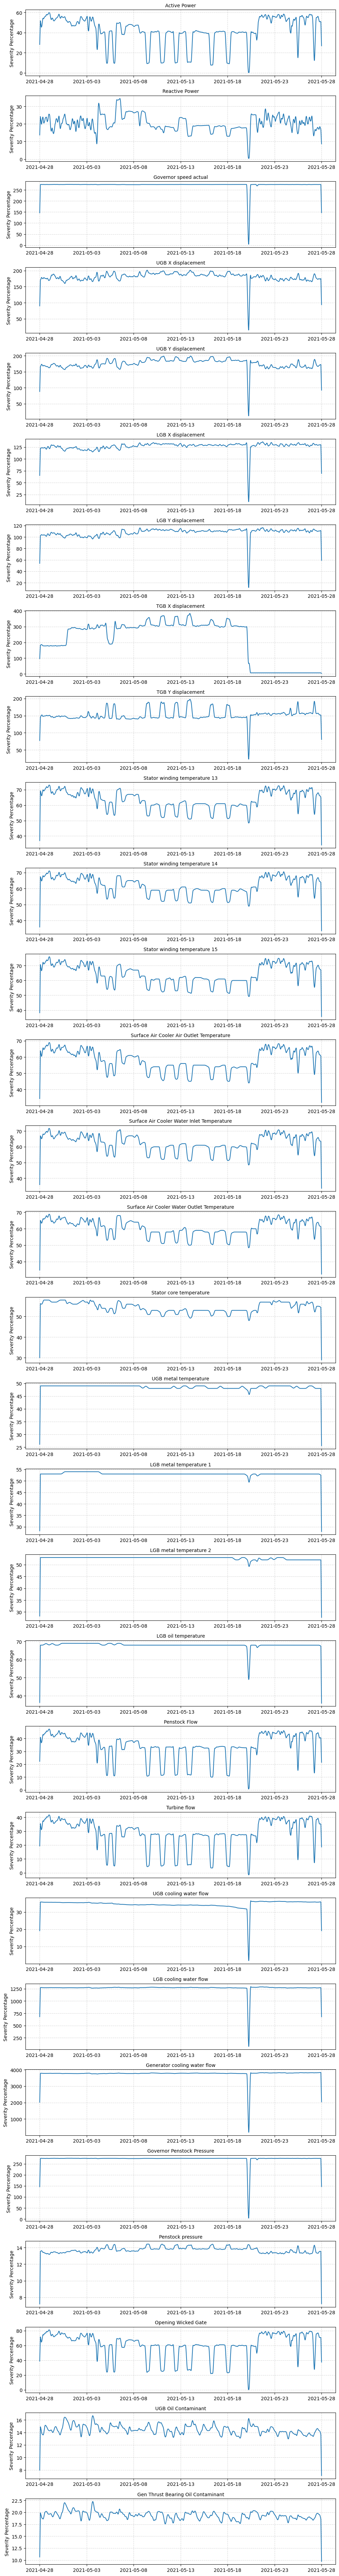

In [5]:
start_date = "2021-04-28T06:15:00"
end_date = "2021-05-28T06:15:00"
severity_trending_datas = fetch_between_dates(start_date, end_date, "db/severity_trendings.db", "severity_trendings")
sensor_datas = fetch_between_dates(start_date, end_date, "db/severity_trendings.db", "original_sensor")

data_timestamp = np.array([convert_timestamp(now_str) for now_str in sensor_datas[:, 1]])
severity_trending_datas = severity_trending_datas[:, 2:].astype(float)
sensor_datas = sensor_datas[:, 2:].astype(float)

date_nums = mdates.date2num(data_timestamp)
tick_locs = np.linspace(date_nums.min(), date_nums.max(), 7)

fig, axes = plt.subplots(30, 1, figsize=(10, 75))
for i, ax in enumerate(axes):
    ax.plot(data_timestamp, np.convolve(sensor_datas[:, i], kernel, mode='same')) 
    ax.set_title(f'{feature_set[i]}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    #ax.set_ylim(0, 100)
    ax.set_ylabel("Severity Percentage")
    ax.set_xticks(tick_locs)  
    
plt.tight_layout()
plt.show()